In [14]:
ls

all_data_decomposed_10ms.csv  invocation_decomposed6.csv  workload_100ms.csv
invocation_decomposed10.csv   invocation_decomposed7.csv  workload_10ms.csv
invocation_decomposed1.csv    invocation_decomposed8.csv  workload_1s.csv
invocation_decomposed2.csv    invocation_decomposed9.csv  workload_200ms.csv
invocation_decomposed3.csv    k3s.yaml                    workload_50ms.csv
invocation_decomposed4.csv    logs/                       workload.py
invocation_decomposed5.csv    Untitled.ipynb


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
files = [
    "invocation_decomposed1.csv",
    "invocation_decomposed2.csv",
    "invocation_decomposed3.csv",
    "invocation_decomposed4.csv",
    "invocation_decomposed5.csv",
    "invocation_decomposed6.csv",
    "invocation_decomposed7.csv",
    "invocation_decomposed8.csv",
    "invocation_decomposed9.csv",
    "invocation_decomposed10.csv"
]


#invocation
dfs = [pd.read_csv(f) for f in files]
all_data = pd.concat(dfs, ignore_index=True)

#power = [
  #   "antela_data.csv",
    # "antela_data1.csv",
     
#]

#dfs = [pd.read_csv(f) for f in power]
#power_df = pd.concat(dfs, ignore_index=True)

In [4]:
all_data.to_csv("all_data_decomposed_10ms.csv", index=False)


In [5]:
power_df.to_csv("power_10ms.csv", index=False)


KeyError: 'Power_W'

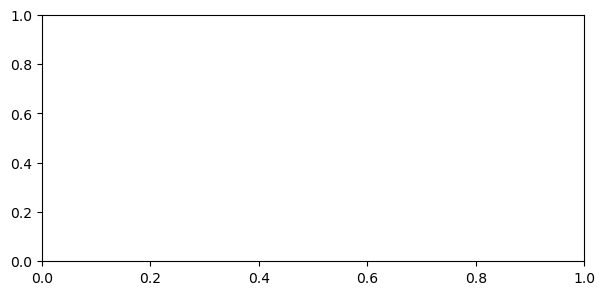

In [26]:
fig, ax = plt.subplots(figsize=(7.0, 3.2))

ax.plot( power_df["Power_W"], color="#2166ac", lw=1.2, alpha=0.9)

mean_w = power_df["Power_W"].mean()
ax.axhline(mean_w, color="#d6604d", lw=1.0, linestyle="--",
           label=f"Mean = {mean_w:.1f} W")

ax.set_xlabel("Time (s)")
ax.set_ylabel("Power (W)")
ax.set_title("Cluster Power Consumption — 10ms Local API-Server", pad=4)
ax.yaxis.set_minor_locator(MultipleLocator(5))

max_w = power_df["Power_W"].max()
ax.axhline(max_w, color="#1a9850", lw=1.0, linestyle=":",
           label=f"Max  = {max_w:.1f} W")
ax.legend(framealpha=0.85, edgecolor="gray", fancybox=False)

fig.tight_layout(pad=0.5)

fig.savefig(os.path.join(BASE, "power_burst.pdf"), format="pdf", bbox_inches="tight")
fig.savefig(os.path.join(BASE, "power_burst.png"), format="png", dpi=300, bbox_inches="tight")
plt.show()

# ── Mémorisation mean et max ──────────────────────────────────────────────────
import json
stats = {"mean_W": round(mean_w, 2), "max_W": round(max_w, 2)}
with open(os.path.join(BASE, "power_stats.json"), "w") as f:
    json.dump(stats, f, indent=2)
print(f"Mean = {mean_w:.2f} W  |  Max = {max_w:.2f} W")
print("Stats sauvegardées : power_stats.json")